In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from prophet import Prophet

In [2]:
stock_df = pd.read_csv('/content/stock_features.csv', parse_dates=["Date"])
stock_df['target'] = stock_df['Close'].shift(-1)

# XGBoost

In [3]:
ticker = 'AAPL'
xgb_df = stock_df[stock_df["Company"] == ticker].copy()

In [4]:
feature_cols = [
    'lag_1', 'lag_5', 'lag_21', 'ema_12', 'ema_26',
    'macd', 'momentum_10', 'volatility_21', 'volume_change',
    'volume_ma_7', 'relative_volume', 'daily_range', 'oc_return'
]

In [5]:
test_size = 0.2

split_idx = int(len(xgb_df) * (1-test_size))
train = xgb_df.iloc[:split_idx].copy()
test = xgb_df.iloc[split_idx:].copy()

In [6]:
X_train = train[feature_cols]
y_train = train['target']

X_test = test[feature_cols]
y_test = test['target']

In [7]:
xgb_model = XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 4,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    verbosity        = 0
)

In [8]:
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [9]:
xgb_dates = test["Date"].values
xgb_actuals = y_test.values
xgb_preds = xgb_model.predict(X_test)

In [10]:
xgb_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = mean_squared_error(y_test, xgb_preds) ** 0.5
xgb_mape = (np.abs((y_test.values - xgb_preds) / y_test.values)).mean() * 100

print(f"  MAE   : ${xgb_mae:.4f}")
print(f"  RMSE  : ${xgb_rmse:.4f}")
print(f"  MAPE  : {xgb_mape:.2f}%")

  MAE   : $21.6353
  RMSE  : $25.9278
  MAPE  : 18.63%


In [11]:
fi = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

In [12]:
fi

,0
ema_12,0.556290
lag_1,0.357627
lag_5,0.037837
lag_21,0.023421
ema_26,0.022990
momentum_10,0.000461
oc_return,0.000350
macd,0.000247
daily_range,0.000202
volatility_21,0.000182


# META Prophet

In [13]:
test_size = 0.2

split_idx = int(len(xgb_df) * (1-test_size))
train = stock_df.iloc[:split_idx].copy()
test = stock_df.iloc[split_idx:].copy()

In [14]:
prophet_df = train[["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"})

In [15]:
mp_model = Prophet(
    daily_seasonality  = False,
    weekly_seasonality = True,
    yearly_seasonality = True,
    changepoint_prior_scale = 0.05,
    seasonality_mode   = "multiplicative",
)

In [16]:
mp_model.fit(prophet_df)

In [17]:
test_future  = test[["Date"]].rename(columns={"Date": "ds"})
test_forecast = mp_model.predict(test_future)
mp_preds = test_forecast["yhat"].values
mp_actuals = test["Close"].values

In [18]:
mp_mae  = mean_absolute_error(mp_actuals, mp_preds)
mp_rmse = mean_squared_error(mp_actuals, mp_preds) ** 0.5
mp_mape = (np.abs((mp_actuals - mp_preds) / mp_actuals)).mean() * 100

print(f"  MAE   : ${mp_mae:.4f}")
print(f"  RMSE  : ${mp_rmse:.4f}")
print(f"  MAPE  : {mp_mape:.2f}%")

  MAE   : $92.4496
  RMSE  : $132.3811
  MAPE  : 179.47%


In [19]:
forecast_days = 90
future = mp_model.make_future_dataframe(periods=forecast_days, freq="B")
mp_forecast = mp_model.predict(future)

# Evaluation

## Historical Price + MA50

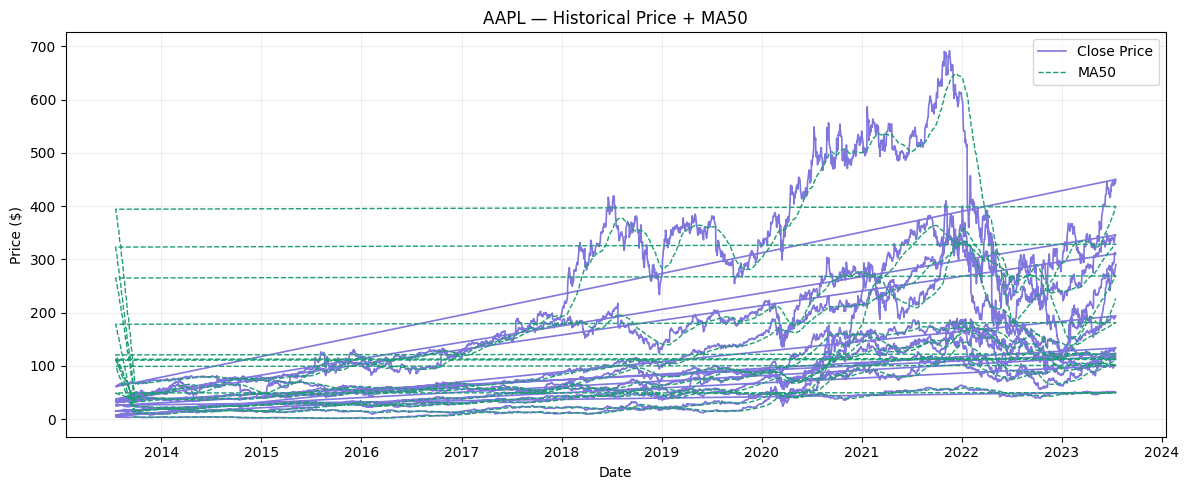

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(
    stock_df["Date"],
    stock_df["Close"],
    color="#7F77DD",
    linewidth=1.2,
    label="Close Price"
)

ma50 = stock_df["Close"].rolling(50).mean()

plt.plot(
    stock_df["Date"],
    ma50,
    color="#1D9E75",
    linewidth=1,
    linestyle="--",
    label="MA50"
)

plt.title(f"{ticker} — Historical Price + MA50")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(alpha=0.2)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

plt.tight_layout()
plt.show()

## XGBoost Test Predictions

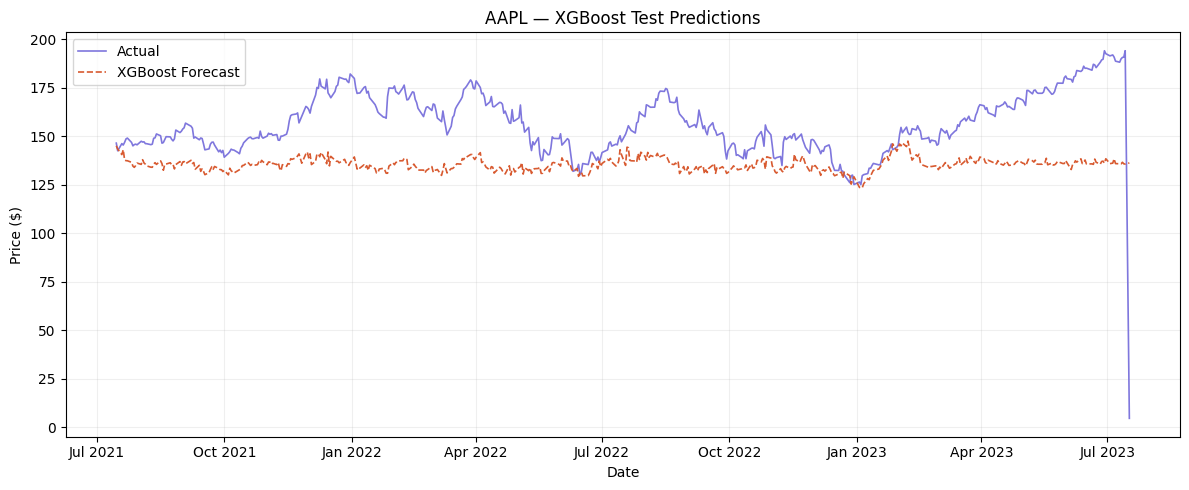

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    xgb_dates,
    xgb_actuals,
    color="#7F77DD",
    linewidth=1.2,
    label="Actual"
)

plt.plot(
    xgb_dates,
    xgb_preds,
    color="#D85A30",
    linewidth=1.2,
    linestyle="--",
    label="XGBoost Forecast"
)

plt.title(f"{ticker} — XGBoost Test Predictions")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(alpha=0.2)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.tight_layout()
plt.show()

## Prophet Future Forecast

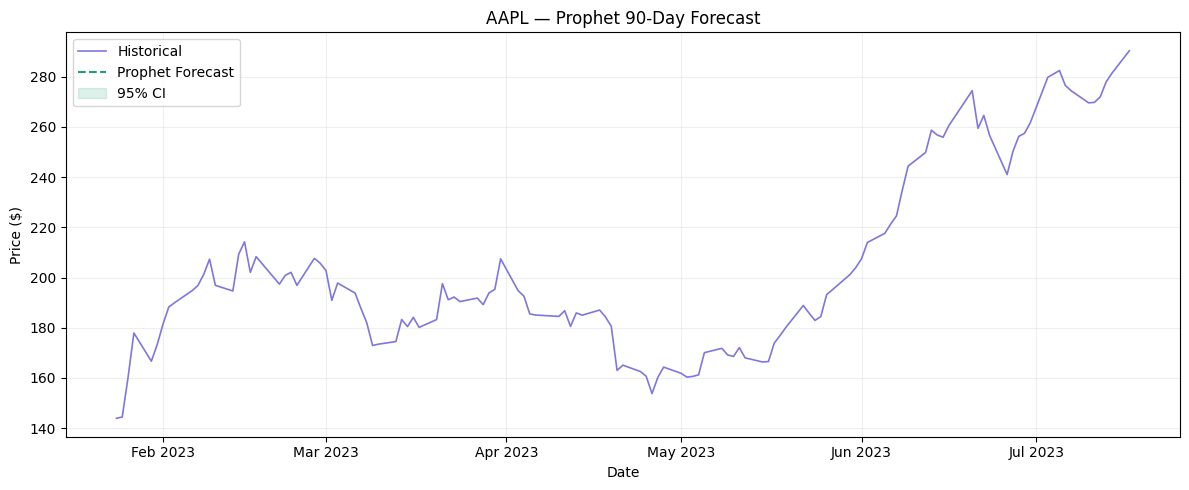

In [22]:
plt.figure(figsize=(12, 5))

hist_tail = stock_df.tail(120)

future_fc = mp_forecast[
    mp_forecast["ds"] > stock_df["Date"].max()
]

plt.plot(
    hist_tail["Date"],
    hist_tail["Close"],
    color="#7F77DD",
    linewidth=1.2,
    label="Historical"
)

plt.plot(
    future_fc["ds"],
    future_fc["yhat"],
    color="#1D9E75",
    linewidth=1.5,
    linestyle="--",
    label="Prophet Forecast"
)

plt.fill_between(
    future_fc["ds"],
    future_fc["yhat_lower"],
    future_fc["yhat_upper"],
    alpha=0.15,
    color="#1D9E75",
    label="95% CI"
)

plt.title(
    f"{ticker} — Prophet {forecast_days}-Day Forecast"
)

plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(alpha=0.2)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.tight_layout()
plt.show()

## Actual vs Predicted Scatter

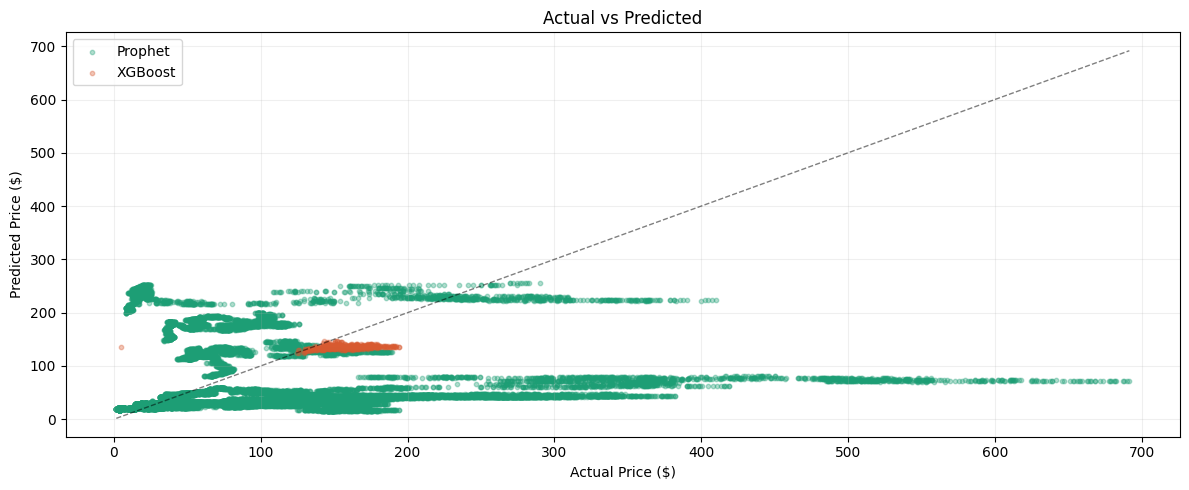

In [23]:
plt.figure(figsize=(12, 5))

plt.scatter(
    mp_actuals,
    mp_preds,
    alpha=0.35,
    s=10,
    color="#1D9E75",
    label="Prophet"
)

plt.scatter(
    xgb_actuals,
    xgb_preds,
    alpha=0.35,
    s=10,
    color="#D85A30",
    label="XGBoost"
)

lims = [
    min(mp_actuals.min(), xgb_actuals.min()),
    max(mp_actuals.max(), xgb_actuals.max())
]

plt.plot(
    lims,
    lims,
    "k--",
    linewidth=1,
    alpha=0.5
)

plt.title("Actual vs Predicted")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()